# Capa 1 — Diagnóstico de contexto y necesidades de las juventudes

Este notebook analiza los datos de **Dato Joven** (Observatorio Nacional de Juventud) procesados por
`scripts/procesar_capa1.py`. Para reproducirlo desde cero:

```bash
python scripts/catalogo_dato_joven.py      # catálogo de tableros (opcional: ya está en fuentes/)
python scripts/extraer_dato_joven.py todo  # extracción -> data/raw/dato_joven/
python scripts/procesar_capa1.py           # limpieza   -> data/processed/
```

**Cómo leer los resultados.** Cada resultado indica su nivel geográfico, y los niveles no se mezclan:

| Nivel | Qué permite afirmar |
|---|---|
| **Distrito** (7 distritos de Lima Este) | Evidencia específica de cada distrito. |
| **Lima Este (agregado)** | Suma de los 7 distritos. Solo para datos distritales. |
| **Lima Metropolitana** | Contexto de los 43 distritos. **No se atribuye a Lima Este.** |
| **Nacional** | Contexto general. **No se atribuye a Lima Este.** |

**Periodo prioritario:** 2022–2026. Las edades llegan como máximo a 29 años (ninguna fuente incluye 30).
Las decisiones metodológicas están documentadas en `fuentes/metodologia_capa1.md`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 200)
P = Path("..") / "data" / "processed"

# Paleta de referencia (skill dataviz): una sola escala por gráfico, tinta neutra para texto.
AZUL, NARANJA = "#2a78d6", "#eb6834"
GRIS_SERIE, TINTA, TINTA_2, GRILLA, EJE, FONDO = "#b5b3ab", "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": FONDO, "axes.facecolor": FONDO, "axes.edgecolor": EJE, "axes.labelcolor": TINTA_2,
    "axes.titlecolor": TINTA, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRILLA, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 110,
})
LIMA_ESTE = ["Ate", "Chaclacayo", "El Agustino", "La Molina", "Lurigancho-Chosica",
             "San Juan de Lurigancho", "Santa Anita"]

## 1. Demografía — evidencia distrital

**Fuente:** Dato Joven, módulo Datos Demográficos. Según el tablero, las estimaciones provienen del
*Repositorio Único Nacional de Información en Salud (REUNIS)* y de las *proyecciones de población del INEI*.

**Advertencia importante.** La población joven de un mismo distrito varía entre años de forma que no
es demográficamente plausible. Por ejemplo, para el conjunto de Lima Metropolitana: +8 % en 2023 y −8 % en
2025, mientras la población total cambia menos de 2 % al año. Por eso se usan **las cifras de 2026 como
estimación de nivel** y **no se interpretan las variaciones entre años** (ver la sección 1.2).

In [2]:
pob = pd.read_csv(P / "capa1_poblacion_resumen.csv", dtype={"ubigeo": str})
p26 = pob[(pob.anio == 2026) & (pob.lima_este | pob.nivel_geografico.isin(
    ["lima_este_agregado", "lima_metropolitana", "nacional"]))].copy()
p26["% 15-19"] = 100 * p26.joven_15_19 / p26.joven_15_29
p26["% 20-24"] = 100 * p26.joven_20_24 / p26.joven_15_29
p26["% 25-29"] = 100 * p26.joven_25_29 / p26.joven_15_29
tabla = p26[["nivel_geografico", "distrito", "joven_15_29", "poblacion_total", "pct_joven",
             "% 15-19", "% 20-24", "% 25-29", "pct_mujer_joven"]].rename(columns={
    "joven_15_29": "jóvenes 15-29", "poblacion_total": "población total", "pct_joven": "% jóvenes",
    "pct_mujer_joven": "% mujeres (jóvenes)"})
tabla.round(1)

,nivel_geografico,distrito,jóvenes 15-29,población total,% jóvenes,% 15-19,% 20-24,% 25-29,% mujeres (jóvenes)
23,distrito,Ate,176748,736312,24.0,31.6,31.1,37.3,53.8
55,distrito,Chaclacayo,9141,45870,19.9,32.7,31.4,35.9,53.7
87,distrito,El Agustino,51742,232282,22.3,32.2,31.0,36.8,54.1
111,distrito,La Molina,32863,174094,18.9,32.2,32.5,35.3,49.3
143,distrito,Lurigancho-Chosica,75532,314899,24.0,32.3,31.0,36.7,53.0
255,distrito,San Juan de Lurigancho,310972,1311300,23.7,31.7,30.8,37.4,53.7
295,distrito,Santa Anita,55281,245241,22.5,31.0,30.7,38.3,53.6
351,lima_este_agregado,Lima Este (7 distritos),712279,3059998,23.3,31.8,31.0,37.2,53.5
359,lima_metropolitana,Lima Metropolitana (43 distritos),2283664,10558495,21.6,31.7,31.4,36.9,53.0
367,nacional,Perú,8037917,34644046,23.2,34.8,31.2,34.0,51.2


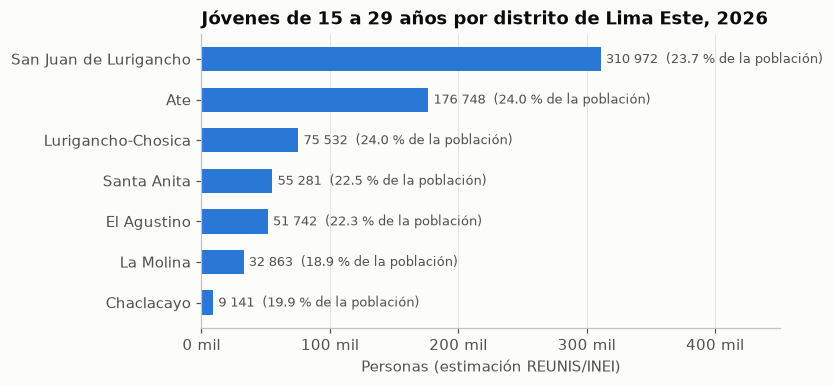

In [3]:
d = p26[p26.lima_este].sort_values("joven_15_29")
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(d.distrito, d.joven_15_29, color=AZUL, height=0.6)
for y, v, pct in zip(d.distrito, d.joven_15_29, d.pct_joven):
    ax.text(v + 4000, y, f"{v:,.0f}  ({pct:.1f} % de la población)".replace(",", " "), va="center",
            color=TINTA_2, fontsize=8.5)
ax.set_title("Jóvenes de 15 a 29 años por distrito de Lima Este, 2026")
ax.set_xlabel("Personas (estimación REUNIS/INEI)")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, d.joven_15_29.max() * 1.45)
ax.xaxis.set_major_formatter(lambda x, _: f"{x/1000:.0f} mil")
plt.tight_layout(); plt.show()

### 1.1 Lectura

- En 2026 viven en los siete distritos alrededor de **712 mil jóvenes de 15 a 29 años**, el 23 % de su
  población. **San Juan de Lurigancho** concentra el 44 % de ellos y **Ate** el 25 %.
- La proporción de jóvenes va de 19 % (La Molina, Chaclacayo) a 24 % (Ate, Lurigancho-Chosica).
- La estructura por edad es parecida en los siete distritos: cerca de un tercio tiene 15–19 años.
- La Molina muestra en 2026 un 49 % de mujeres entre los jóvenes, frente a 53–54 % en los demás distritos y
  en años anteriores. Es probable que sea un efecto de la estimación (ver 1.2), no un cambio real.

### 1.2 Estabilidad de las series

La tabla muestra la variación anual de la población joven. Las oscilaciones de ±5–10 % en un año, sin
cambios equivalentes en la población total, indican cambios en el método de estimación por edad.

In [4]:
dist = pob[pob.lima_este | pob.nivel_geografico.isin(["lima_este_agregado", "lima_metropolitana"])]
var = dist.pivot_table(index="distrito", columns="anio", values="joven_15_29").pct_change(axis=1) * 100
var_total = dist.pivot_table(index="distrito", columns="anio", values="poblacion_total").pct_change(axis=1) * 100
print("Variación anual de la población joven (%)")
display(var.loc[:, 2022:].round(1))
print("Variación anual de la población total (%)")
display(var_total.loc[:, 2022:].round(1))

Variación anual de la población joven (%)


anio,2022,2023,2024,2025,2026
distrito,,,,,
Ate,-5.1,10.9,1.1,-6.5,1.4
Chaclacayo,8.5,6.3,-1.8,-11.1,1.5
El Agustino,-1.3,8.4,-0.6,-10.3,1.4
La Molina,13.6,2.2,-0.0,-10.1,1.5
Lima Este (7 distritos),-4.2,9.6,1.8,-6.9,1.4
Lima Metropolitana (43 distritos),0.9,8.1,1.2,-8.0,1.5
Lurigancho-Chosica,2.6,12.4,1.9,-8.8,1.5
San Juan de Lurigancho,-6.6,9.8,3.0,-5.9,1.4
Santa Anita,-10.6,7.3,2.3,-5.2,1.4


Variación anual de la población total (%)


anio,2022,2023,2024,2025,2026
distrito,,,,,
Ate,2.7,1.7,0.7,1.4,1.2
Chaclacayo,2.4,1.4,-2.1,0.3,1.0
El Agustino,2.4,1.5,-1.0,-1.2,1.6
La Molina,3.1,1.0,-0.8,2.4,1.5
Lima Este (7 distritos),3.8,1.7,1.3,1.5,1.2
Lima Metropolitana (43 distritos),2.4,1.7,0.7,1.8,1.3
Lurigancho-Chosica,18.1,3.2,2.0,0.0,1.5
San Juan de Lurigancho,2.1,1.6,2.3,2.1,1.2
Santa Anita,2.8,0.8,1.6,2.8,0.9


## 2. Organizaciones juveniles — evidencia distrital

**Fuente:** Registro Nacional de Organizaciones Juveniles (RENOJ), en Dato Joven. Se cuentan las
organizaciones **acreditadas** entre 2019 y 2026 según su distrito. No indica si siguen activas.
Para comparar distritos de distinto tamaño se usa la tasa por 10 mil jóvenes (población 2026).

In [5]:
ren = pd.read_csv(P / "capa1_renoj_resumen_distritos.csv", dtype={"ubigeo": str})
mediana = ren.organizaciones_por_10mil_jovenes.median()
display(ren[ren.lima_este][["distrito", "organizaciones_acumuladas", "acreditadas_2022_2026",
                            "joven_15_29", "organizaciones_por_10mil_jovenes"]]
        .sort_values("organizaciones_por_10mil_jovenes", ascending=False).round(1))
print(f"Mediana de los 43 distritos de Lima Metropolitana: {mediana:.1f} organizaciones por 10 mil jóvenes")

,distrito,organizaciones_acumuladas,acreditadas_2022_2026,joven_15_29,organizaciones_por_10mil_jovenes
13,La Molina,47.0,27.0,32863,14.3
6,Chaclacayo,3.0,2.0,9141,3.3
36,Santa Anita,18.0,12.0,55281,3.3
10,El Agustino,12.0,9.0,51742,2.3
31,San Juan de Lurigancho,60.0,46.0,310972,1.9
2,Ate,30.0,15.0,176748,1.7
17,Lurigancho-Chosica,12.0,9.0,75532,1.6


Mediana de los 43 distritos de Lima Metropolitana: 3.3 organizaciones por 10 mil jóvenes


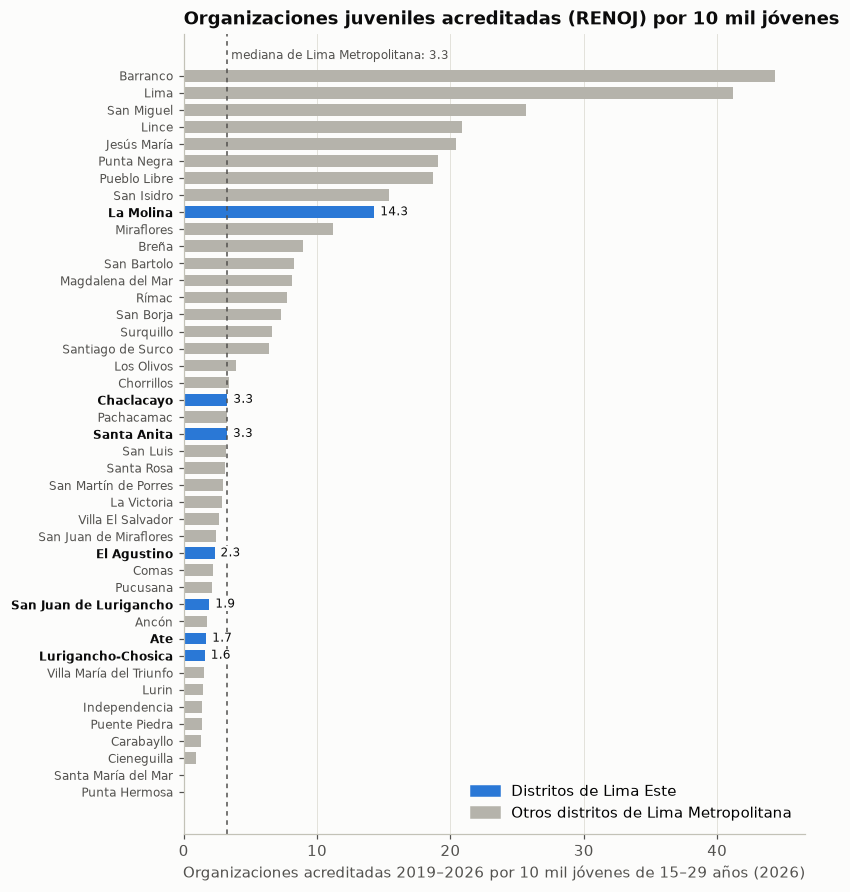

In [6]:
def barras_43(df, col, titulo, xlabel, ref, ref_label):
    d = df.sort_values(col)
    colores = [AZUL if le else GRIS_SERIE for le in d.lima_este]
    fig, ax = plt.subplots(figsize=(7.5, 8.2))
    ax.barh(d.distrito, d[col], color=colores, height=0.68)
    ax.axvline(ref, color=TINTA_2, lw=1, ls=(0, (3, 3)))
    ax.text(ref, len(d) - 0.2, f" {ref_label}", color=TINTA_2, fontsize=8, va="bottom")
    for y, (v, le) in enumerate(zip(d[col], d.lima_este)):
        if le:
            ax.text(v + d[col].max() * 0.01, y, f"{v:.1f}", va="center", color=TINTA, fontsize=8,
                    bbox=dict(facecolor=FONDO, edgecolor="none", pad=0.6))
    for lbl, le in zip(ax.get_yticklabels(), d.lima_este):
        lbl.set_color(TINTA if le else TINTA_2); lbl.set_fontweight("bold" if le else "normal")
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", visible=False)
    ax.set_title(titulo); ax.set_xlabel(xlabel)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=AZUL, label="Distritos de Lima Este"),
                       Patch(color=GRIS_SERIE, label="Otros distritos de Lima Metropolitana")],
              loc="lower right")
    plt.tight_layout(); plt.show()

barras_43(ren, "organizaciones_por_10mil_jovenes",
          "Organizaciones juveniles acreditadas (RENOJ) por 10 mil jóvenes",
          "Organizaciones acreditadas 2019–2026 por 10 mil jóvenes de 15–29 años (2026)",
          mediana, f"mediana de Lima Metropolitana: {mediana:.1f}")

In [7]:
org = pd.read_csv(P / "capa1_renoj_organizaciones.csv", dtype={"ubigeo": str})
org["grupo"] = np.where(org.lima_este, "Lima Este", "Resto de Lima Metropolitana")
tem = org.pivot_table(index="tematica", columns="grupo", values="organizaciones", aggfunc="sum", fill_value=0)
for g in list(tem.columns):
    tem[f"% {g}"] = 100 * tem[g] / tem[g].sum()
display(tem.sort_values("Lima Este", ascending=False).round(1))
print("Organizaciones de Lima Este por año de acreditación:",
      org[org.lima_este].groupby("anio_acreditacion").organizaciones.sum().to_dict())

grupo,Lima Este,Resto de Lima Metropolitana,% Lima Este,% Resto de Lima Metropolitana
tematica,,,,
Otros,87,428,47.8,50.1
Educación y desarrollo,35,136,19.2,15.9
Acción social y voluntariado,28,112,15.4,13.1
Cultura y arte,20,112,11.0,13.1
Ambiente y sostenibilidad,8,22,4.4,2.6
Inclusión y derechos,2,14,1.1,1.6
Salud y bienestar,2,13,1.1,1.5
Deporte y recreación,0,11,0.0,1.3
Participación y ciudadanía,0,7,0.0,0.8


Organizaciones de Lima Este por año de acreditación: {2019: 6, 2020: 21, 2021: 35, 2022: 11, 2023: 33, 2024: 30, 2025: 36, 2026: 10}


### 2.1 Lectura

- Los siete distritos suman **182 organizaciones juveniles acreditadas** (2019–2026), 124 de ellas
  acreditadas entre 2022 y 2026.
- En relación con su población joven, **La Molina** (14,3 por 10 mil) está muy por encima de la mediana
  metropolitana (3,3). Chaclacayo y Santa Anita están en la mediana. **San Juan de Lurigancho, Ate,
  Lurigancho-Chosica y El Agustino** tienen las densidades más bajas (1,6–2,3), pese a concentrar la mayor
  parte de la población joven.
- Por temática, Lima Este se parece al resto de Lima Metropolitana. Predominan "Otros", "Educación y
  desarrollo" y "Acción social y voluntariado". **No hay ninguna organización acreditada con temática
  de deporte ni de participación y ciudadanía** en los siete distritos. Cultura y arte reúne 20 organizaciones (11 %).
- **Límite:** el registro depende de que las organizaciones se acrediten. Una densidad baja puede reflejar
  menos registro, no necesariamente menos organización juvenil.

## 3. Voluntariado — evidencia distrital, **solo como señal complementaria**

**Fuente:** Programa de Voluntariado Juvenil (SENAJU), en Dato Joven. Son personas que **se inscribieron
por iniciativa propia**: no representan a la juventud de su distrito. La tabla de inscritos no tiene año.

,distrito,personas_inscritas,inscritas_por_10mil_jovenes
13,La Molina,143.0,43.5
6,Chaclacayo,35.0,38.3
36,Santa Anita,153.0,27.7
2,Ate,479.0,27.1
10,El Agustino,120.0,23.2
31,San Juan de Lurigancho,679.0,21.8
17,Lurigancho-Chosica,118.0,15.6


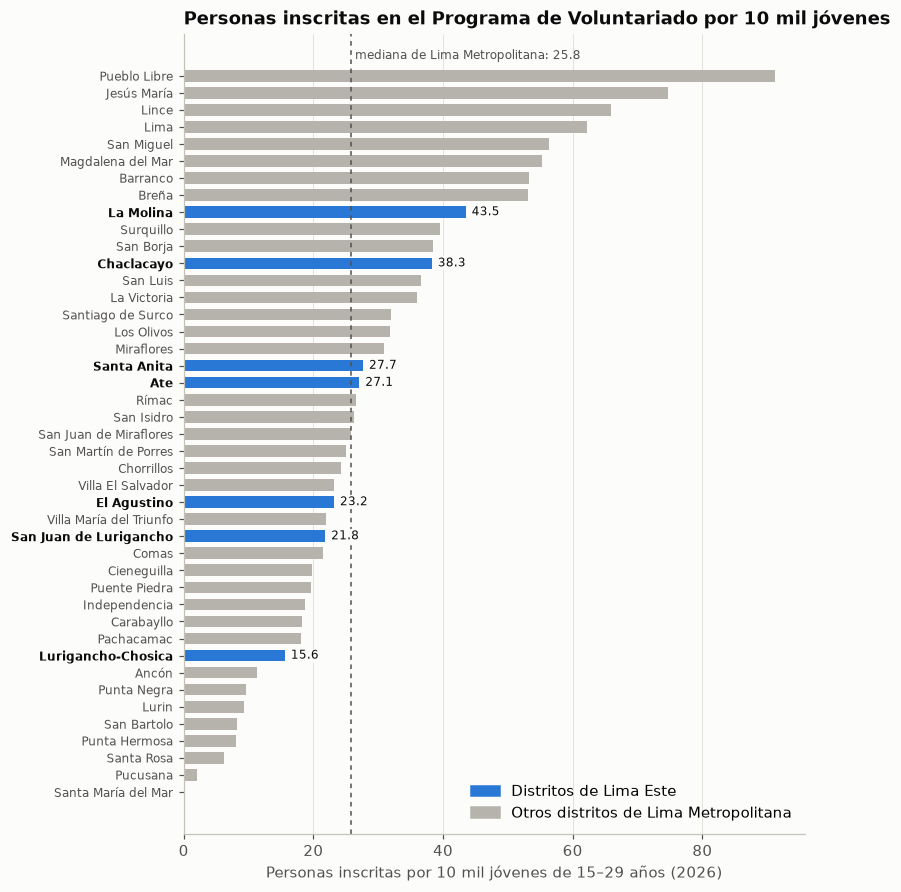

In [8]:
vr = pd.read_csv(P / "capa1_voluntariado_resumen_distritos.csv", dtype={"ubigeo": str})
med_v = vr.inscritas_por_10mil_jovenes.median()
display(vr[vr.lima_este][["distrito", "personas_inscritas", "inscritas_por_10mil_jovenes"]]
        .sort_values("inscritas_por_10mil_jovenes", ascending=False).round(1))
barras_43(vr, "inscritas_por_10mil_jovenes", "Personas inscritas en el Programa de Voluntariado por 10 mil jóvenes",
          "Personas inscritas por 10 mil jóvenes de 15–29 años (2026)", med_v,
          f"mediana de Lima Metropolitana: {med_v:.1f}")

In [9]:
vol = pd.read_csv(P / "capa1_voluntariado_distritos.csv", dtype={"ubigeo": str})
vol["grupo"] = np.where(vol.lima_este, "Lima Este", "Resto de Lima Metropolitana")
totales = vol[vol.variable == "SEXO"].groupby("grupo").personas.sum()

def perfil(variables, solo_si=False):
    d = vol[vol.variable.isin(variables)]
    if solo_si:
        d = d[d.valor == "SI"]
    t = d.groupby(["variable", "valor", "grupo"]).personas.sum().unstack("grupo")
    return (100 * t / totales).round(1)

print("Personas inscritas:", totales.to_dict())
print("Perfil (% de las personas inscritas)")
display(perfil(["SEXO", "RANGO_EDAD", "OCUPACION", "PARTICIPA_ORGANIZACIÓN_JUVENIL"]))
intereses = [v for v in vol.variable.unique() if v.startswith("INTERES_")]
experiencia = [v for v in vol.variable.unique() if v.startswith("EXPERIENCIA_VOLUNTARIADO_")]
print("Intereses declarados (% que marcó SÍ)")
display(perfil(intereses, solo_si=True))
print("Experiencia previa de voluntariado por temática (% que marcó SÍ)")
display(perfil(experiencia, solo_si=True).sort_values("Lima Este", ascending=False))

Personas inscritas: {'Lima Este': 1727, 'Resto de Lima Metropolitana': 4364}
Perfil (% de las personas inscritas)


grupo                                               Lima Este  Resto de Lima Metropolitana
variable                       valor                                                      
OCUPACION                      BUSCA EMPLEO               9.9                          9.2
                               ESTUDIA                   65.4                         66.3
                               ESTUDIA Y TRABAJA         15.5                         15.1
                               TRABAJA                    7.6                          8.0
                               TRABAJA SIN SALARIO        1.6                          1.4
PARTICIPA_ORGANIZACIÓN_JUVENIL NO                        86.7                         83.8
                               SI                        13.3                         16.2
RANGO_EDAD                     15 a 19                   45.9                         43.1
                               20 a 24                   40.9                         43.8
                               25 a 29                   13.3                         13.1
SEXO                           Hombre                    15.1                         15.7
                               Mujer                     84.9                         84.3

Intereses declarados (% que marcó SÍ)


,grupo,Lima Este,Resto de Lima Metropolitana
variable,valor,,
INTERES_VOLUNTARIADO_EDUCACIÓN_INTEGRAL,SI,92.6,92.9
INTERES_VOLUNTARIADO_EDUCACIÓN_PARA_LA_EMPLEABILIDAD,SI,81.3,79.7
INTERES_VOLUNTARIADO_PARTICIPACIÓN_CIUDADANA,SI,88.7,85.6
"INTERES_VOLUNTARIADO_PARTICIPACIÓN_JUVENIL_MEDIANTE_EL_DEPORTE,_EL_ARTE_Y_LA_CULTURA",SI,92.5,91.6
INTERES_VOLUNTARIADO_POBLACIONES_SITUACIÓN_VULNERABILIDAD,SI,91.4,89.5
INTERES_VOLUNTARIADO_SALUD_MENTAL_Y_BIENESTAR,SI,90.3,90.4


Experiencia previa de voluntariado por temática (% que marcó SÍ)


,grupo,Lima Este,Resto de Lima Metropolitana
variable,valor,,
EXPERIENCIA_VOLUNTARIADO_EDUCACIÓN,SI,38.9,40.6
EXPERIENCIA_VOLUNTARIADO_MEDIO_AMBIENTE,SI,31.2,31.5
EXPERIENCIA_VOLUNTARIADO_CULTURA,SI,22.8,25.4
EXPERIENCIA_VOLUNTARIADO_SALUD,SI,20.0,21.6
EXPERIENCIA_VOLUNTARIADO_CIENCIA,SI,11.3,12.2
EXPERIENCIA_VOLUNTARIADO_DEMOCRACIA,SI,11.1,12.7
EXPERIENCIA_VOLUNTARIADO_DEPORTE,SI,10.6,11.6
EXPERIENCIA_VOLUNTARIADO_ECONOMÍA,SI,5.3,8.2


### 3.1 Lectura

- Hay **1 727 personas inscritas** con residencia registrada en los siete distritos. Salvo La Molina y
  Chaclacayo, los distritos de Lima Este están cerca o por debajo de la mediana metropolitana de inscripción
  por 10 mil jóvenes. Lurigancho-Chosica tiene la tasa más baja.
- El perfil es casi idéntico al del resto de Lima Metropolitana: **85 % mujeres**, 46 % de 15–19 años y
  **65 % solo estudia**; 10 % busca empleo.
- **Los intereses declarados casi no discriminan:** entre 81 % y 93 % marca "sí" en cada una de las seis
  temáticas. No sirven para priorizar temas; solo indican una disposición general a participar.
- La **experiencia previa** sí diferencia: educación (39 %), medio ambiente (31 %), cultura (23 %) y salud
  (20 %) superan claramente a deporte (11 %), ciencia (11 %), democracia (11 %) y economía (5 %).
- Todo esto describe a **quienes se inscribieron**, no a la juventud de los distritos.

### 3.2 ¿Qué proporción de cada grupo se inscribió? (no calculable)

Se evaluó calcular, por ejemplo, qué porcentaje de los jóvenes que solo estudian se inscribió en el programa.
**No es válido** (decisión D18 en `fuentes/metodologia_capa1.md`):
1. **Sin periodo:** el registro no tiene fecha de inscripción. Es un acumulado de un periodo desconocido, y la
   situación de estudio o trabajo se anotó al inscribirse.
2. **Categorías distintas:** el registro no tiene "ni estudia ni trabaja" y su categoría "busca empleo" no
   equivale a NINI.
3. **Sin denominador distrital:** la población por situación de actividad solo existe para Lima Metropolitana.

Lo único comparable es la **composición**: la tabla siguiente pone lado a lado la distribución de los inscritos y
la de la población joven de Lima Metropolitana. Es una comparación descriptiva, no una tasa, y no indica causas.

In [10]:
occ = vol[vol.variable == "OCUPACION"].copy()
grupo_registro = {"ESTUDIA": "Solo estudia", "ESTUDIA Y TRABAJA": "Estudia y trabaja", "TRABAJA": "Solo trabaja",
                  "TRABAJA SIN SALARIO": "Solo trabaja", "BUSCA EMPLEO": "Busca empleo (registro) / NINI (población)"}
occ["grupo"] = occ.valor.map(grupo_registro)
insc = occ.groupby(["grupo", occ.lima_este.map({True: "Inscritos de Lima Este", False: "Inscritos del resto de Lima Metropolitana"})]
                   ).personas.sum().unstack()
insc = 100 * insc / insc.sum()
enc_act = pd.read_csv(P / "capa1_indicadores_encuestas.csv")
act = enc_act[(enc_act.tablero == "Actividades que realizan los jóvenes") & (enc_act.nivel_geografico == "lima_metropolitana")
              & (enc_act.desagregacion == "total") & enc_act.anio.between(2022, 2025)]
grupo_pob = {"SOLO ESTUDIA": "Solo estudia", "TRABAJA Y ESTUDIA": "Estudia y trabaja", "SOLO TRABAJA": "Solo trabaja",
             "NINI": "Busca empleo (registro) / NINI (población)"}
pob = act.assign(grupo=act.indicador.map(grupo_pob)).groupby("grupo").valor.agg(["min", "max"])
insc["Población joven de Lima Metropolitana 2022–2025 (Dato Joven)"] = [f"{a:.0f}–{b:.0f}" for a, b in pob.reindex(insc.index).to_numpy()]
insc.round(1)

lima_este,Inscritos de Lima Este,Inscritos del resto de Lima Metropolitana,Población joven de Lima Metropolitana 2022–2025 (Dato Joven)
grupo,,,
Busca empleo (registro) / NINI (población),9.9,9.2,18–20
Estudia y trabaja,15.5,15.1,9–12
Solo estudia,65.4,66.3,26–30
Solo trabaja,9.2,9.4,43–45


**Lectura:** entre los inscritos predominan quienes solo estudian (alrededor de dos tercios), mientras que en la
población joven de Lima Metropolitana son entre un cuarto y un tercio; quienes solo trabajan son minoría entre los
inscritos y mayoría en la población. Solo muestra **quién llega al programa**; no permite decir qué proporción de
cada grupo se inscribe ni por qué.

## 4. Registros administrativos por distrito — datos sensibles, solo agregados

**Fuentes (vía Dato Joven):** certificados de nacido vivo (CNV), casos atendidos en los Centros Emergencia
Mujer y Familia (CEM), certificación de discapacidad (MINSA) y Registro Nacional de la Persona con
Discapacidad (CONADIS).

**Protección de datos.** Solo se usan conteos agregados. Todo conteo **menor de 10 se oculta**, y se aplica
ocultación complementaria para que una celda oculta no pueda deducirse restando del total. Si un distrito
no aparece en un año, es porque no tiene casos registrados.

**Qué miden (y qué no):**
- **CNV:** nacimientos de madres de 15 a 19 años, según el **distrito de residencia de la madre**
  (verificado: los partos se atienden en establecimientos de otros distritos). Mide nacimientos, no
  embarazos. 2026 solo llega hasta junio.
- **CEM:** casos **atendidos**, según el **distrito de domicilio de la víctima** (verificado). Depende del
  acceso a los servicios y de la decisión de acudir. **No mide cuánta violencia hay.**
- **Discapacidad:** certificados emitidos e inscripciones en el CONADIS. Dependen del acceso a los trámites,
  **no miden la prevalencia**.

Las tasas usan el promedio anual de 2022–2025 y la población de 2026 (decisión D5).

In [11]:
reg = pd.read_csv(P / "capa1_registros_resumen.csv", dtype={"ubigeo": str})
nombres = {"maternidad_adolescente": "Maternidad adolescente (por 1 000 mujeres de 15–19)",
           "violencia_atendida_cem": "Casos atendidos en los CEM (por 10 000 jóvenes)",
           "discapacidad_certificados": "Certificados de discapacidad (por 10 000 jóvenes)",
           "discapacidad_conadis": "Inscripciones en el CONADIS (por 10 000 jóvenes)"}
t = reg[reg.lima_este].pivot_table(index="distrito", columns="registro", values="tasa").rename(columns=nombres)
med = reg.groupby("registro").tasa.median().rename(nombres)
t.loc["Mediana de Lima Metropolitana (43 distritos)"] = med
t.round(1)

registro,Certificados de discapacidad (por 10 000 jóvenes),Inscripciones en el CONADIS (por 10 000 jóvenes),Maternidad adolescente (por 1 000 mujeres de 15–19),Casos atendidos en los CEM (por 10 000 jóvenes)
distrito,,,,
Ate,6.0,6.9,17.1,51.1
Chaclacayo,3.0,10.7,13.3,67.3
El Agustino,22.2,11.0,24.2,39.6
La Molina,3.7,8.9,6.3,42.8
Lurigancho-Chosica,5.0,4.9,13.6,47.0
San Juan de Lurigancho,6.9,6.5,15.9,36.2
Santa Anita,24.6,7.3,18.9,55.2
Mediana de Lima Metropolitana (43 distritos),16.1,9.3,16.2,48.3


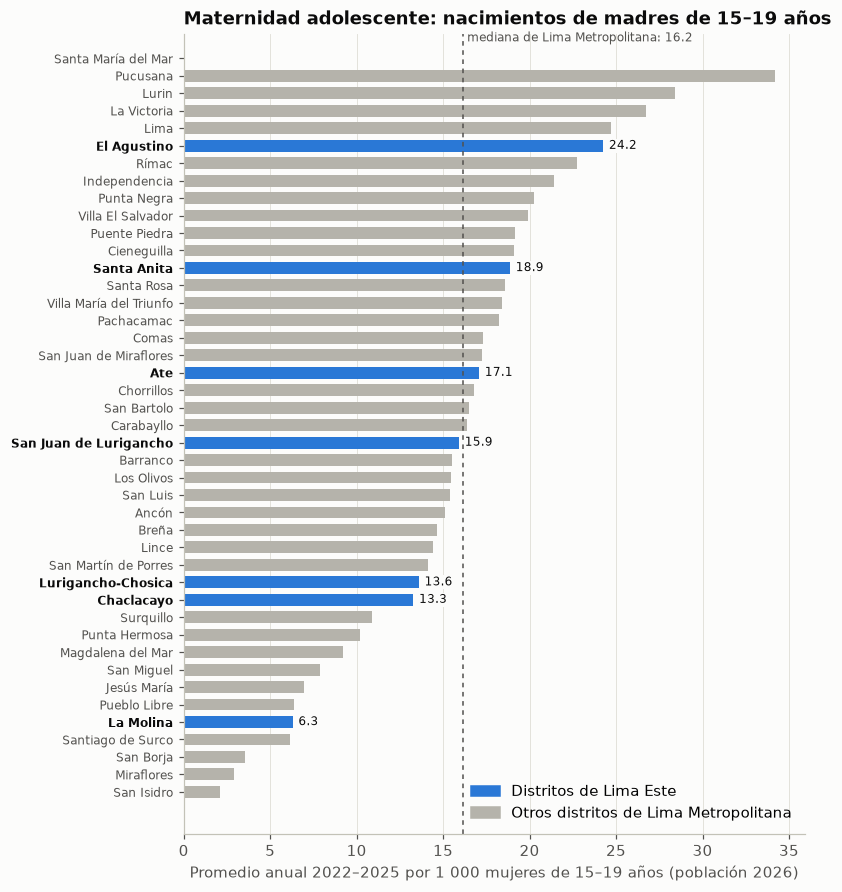

In [12]:
mat = reg[reg.registro == "maternidad_adolescente"].copy()
barras_43(mat, "tasa", "Maternidad adolescente: nacimientos de madres de 15–19 años",
          "Promedio anual 2022–2025 por 1 000 mujeres de 15–19 años (población 2026)",
          mat.tasa.median(), f"mediana de Lima Metropolitana: {mat.tasa.median():.1f}")

In [13]:
anual = pd.read_csv(P / "capa1_registros_distrito_anio.csv", dtype={"ubigeo": str})
le_anual = anual[(anual.nivel_geografico == "lima_este_agregado")]
tabla_anual = le_anual.pivot_table(index="registro", columns="anio", values="casos").rename(index=nombres)
print("Lima Este (7 distritos): casos registrados por año (2026 parcial)")
display(tabla_anual.round(0))
des = pd.read_csv(P / "capa1_registros_distrito_desagregado.csv", dtype={"ubigeo": str})
print("Lima Este (7 distritos), 2022–2025: distribución de los casos (%)")
display(des[des.ubigeo == "LIMA_ESTE"].pivot_table(index=["registro", "variable", "categoria"],
                                                   values="pct_del_distrito").round(1))

Lima Este (7 distritos): casos registrados por año (2026 parcial)


anio,2019,2020,2021,2022,2023,2024,2025,2026
registro,,,,,,,,
Certificados de discapacidad (por 10 000 jóvenes),293.0,131.0,267.0,379.0,541.0,748.0,829.0,NaN
Inscripciones en el CONADIS (por 10 000 jóvenes),491.0,159.0,358.0,442.0,485.0,508.0,554.0,310.0
Maternidad adolescente (por 1 000 mujeres de 15–19),3439.0,3010.0,2219.0,2202.0,1900.0,1852.0,1654.0,791.0
Casos atendidos en los CEM (por 10 000 jóvenes),4195.0,2113.0,2926.0,3068.0,3196.0,3034.0,3093.0,NaN


Lima Este (7 distritos), 2022–2025: distribución de los casos (%)


pct_del_distrito
registro                  variable           categoria                                
discapacidad_certificados grupo_edad         15 a 19                              38.2
                                             20 a 24                              31.8
                                             25 a 29                              30.0
                          sexo               HOMBRE                               60.5
                                             MUJER                                39.5
discapacidad_conadis      rango_edad         15 a 19                              45.2
                                             20 a 24                              31.4
                                             25 a 29                              23.4
                          sexo               HOMBRE                               65.5
                                             MUJER                                34.5
maternidad_adolescente    rango_edad         15 a 16 años                         20.0
                                             17 a 18 años                         44.8
                                             19 años                              35.2
violencia_atendida_cem    grupo_edad_victima 15 a 19                              40.9
                                             20 a 24                              28.2
                                             25 a 29                              30.9
                          sexo_victima       HOMBRE                                6.0
                                             MUJER                                94.0
violencia_cem_por_tipo    tipo_violencia     Económica o Patrimonial               0.1
                                             Física                               38.9
                                             Psicológica                          26.1
                                             Sexual                               34.9

### 4.1 Lectura (evidencia distrital)

- **Maternidad adolescente.** En los siete distritos se registraron 1 654 nacimientos de madres de 15–19
  años en 2025, **menos de la mitad que en 2019** (3 439). La tasa promedio 2022–2025 es más alta en
  **El Agustino** (24 por 1 000 mujeres de 15–19), **Santa Anita** (19) y **Ate** (17) que la mediana
  metropolitana (16). La Molina tiene la más baja (6). El 45 % de las madres tiene 17–18 años y el 20 %,
  15–16.
- **Violencia atendida en los CEM.** Entre 2022 y 2025 se atendieron unos 3 000 casos al año de jóvenes con
  domicilio en Lima Este. El **94 % son mujeres** y el **41 % tiene 15–19 años**. Por tipo: física (39 %),
  **sexual (35 %)** y psicológica (26 %). Chaclacayo, Santa Anita y Ate superan la mediana metropolitana
  de casos por 10 mil jóvenes. San Juan de Lurigancho y El Agustino están por debajo. Estas diferencias
  pueden reflejar acceso a los servicios, no más o menos violencia.
- **Discapacidad.** Las tasas de certificación varían mucho entre distritos: Santa Anita (25) y El Agustino
  (22) frente a Ate (6) o Lurigancho-Chosica (5). Es más probable que reflejen el acceso a la certificación
  que diferencias reales de prevalencia. En ambos registros predominan los hombres (61–66 %).

## 5. Contexto de Lima Metropolitana — encuestas nacionales

**Fuentes:** ENAHO, EPEN, ENDES y ENAPRES (INEI), procesadas por Dato Joven. Son estimaciones por
muestreo representativas de **Lima Metropolitana (43 distritos)**. **No describen a Lima Este.**

**Precisión.** Cada valor trae su coeficiente de variación (CV). Siguiendo a la fuente (que pone entre
paréntesis los valores con CV > 15 %), esos valores se marcan como **referenciales**. Para los cambios
entre años se calcula una prueba aproximada. Su error estándar se estima como `valor × CV / 100` y se
considera que un cambio es distinguible del error de muestreo si |z| ≥ 1,96. La prueba supone muestras
independientes y es solo orientativa.

In [14]:
enc = pd.read_csv(P / "capa1_indicadores_encuestas.csv")
enc = enc[~enc.excluida_por_etiqueta_ambigua & ~enc.sin_dato]
enc["ee"] = enc.valor * enc.cv / 100

def resumen_lm(dimension=None):
    lm = enc[(enc.nivel_geografico == "lima_metropolitana") & (enc.desagregacion == "total") & (enc.anio >= 2022)]
    if dimension:
        lm = lm[lm.dimension == dimension]
    filas = []
    for (dim, tab, ind), g in lm.groupby(["dimension", "tablero", "indicador"]):
        g = g.sort_values("anio"); a, b = g.iloc[0], g.iloc[-1]
        z = (b.valor - a.valor) / np.hypot(a.ee, b.ee) if len(g) > 1 and np.hypot(a.ee, b.ee) > 0 else np.nan
        sexo = enc[(enc.nivel_geografico == "lima_metropolitana") & (enc.tablero == tab) &
                   (enc.indicador == ind) & (enc.anio == b.anio)].set_index("desagregacion").valor
        nac = enc[(enc.nivel_geografico == "nacional") & (enc.desagregacion == "total") & (enc.tablero == tab) &
                  (enc.indicador == ind) & (enc.anio == b.anio)].valor
        filas.append({"dimensión": dim, "indicador": ind.capitalize()[:60], "población": b.poblacion,
                      "fuente": b.fuente, "años": f"{int(a.anio)}–{int(b.anio)}",
                      "valor inicial": a.valor, "último valor": b.valor, "unidad": b.unidad,
                      "cambio": b.valor - a.valor,
                      "cambio distinguible": ("sí" if abs(z) >= 1.96 else "no") if not np.isnan(z) else "—",
                      "referencial": "sí" if b.referencial else "",
                      "mujeres": sexo.get("mujer"), "hombres": sexo.get("hombre"),
                      "Perú": nac.iloc[0] if len(nac) else np.nan})
    return pd.DataFrame(filas).round(1)

resumen = resumen_lm()
resumen.to_csv(P / "capa1_resumen_lima_metropolitana.csv", index=False)
print(f"{len(resumen)} indicadores de Lima Metropolitana con datos en 2022 o después")

107 indicadores de Lima Metropolitana con datos en 2022 o después


### Educación (Lima Metropolitana)

In [15]:
resumen[resumen["dimensión"] == "Educación"].drop(columns="dimensión")

,indicador,población,fuente,años,valor inicial,último valor,unidad,cambio,cambio distinguible,referencial,mujeres,hombres,Perú
0,Asistencia no universitaria,17-24,ENAHO,2022–2025,11.2,11.4,%,0.2,no,,12.1,10.7,10.7
1,Asistencia universitaria,17-24,ENAHO,2022–2025,19.6,25.6,%,6.0,sí,,25.5,25.6,22.4
2,Años escolaridad,15-29,ENAHO,2022–2025,11.7,11.9,años,0.2,sí,,12.1,11.8,11.5
3,Secundaria completa,17-18,ENAHO,2022–2025,85.6,82.6,%,-3.0,no,,82.6,82.5,82.7
4,Superior completa,22-24,ENAHO,2022–2025,20.8,24.4,%,3.6,no,,28.7,19.8,24.4
5,Nivel primaria,15-29,ENAHO,2022–2025,2.7,2.5,%,-0.2,no,sí,1.9,3.0,4.4
6,Nivel secundaria,15-29,ENAHO,2022–2025,55.1,49.7,%,-5.4,sí,,49.1,50.2,53.5
7,Nivel superior no universitaria,15-29,ENAHO,2022–2025,16.5,17.2,%,0.7,no,,17.1,17.2,16.8
8,Nivel superior universitaria,15-29,ENAHO,2022–2025,25.6,30.7,%,5.1,sí,,31.8,29.6,25.3


### Empleo y situación laboral (Lima Metropolitana)

In [16]:
resumen[resumen["dimensión"] == "Empleo y situación laboral"].drop(columns="dimensión")

,indicador,población,fuente,años,valor inicial,último valor,unidad,cambio,cambio distinguible,referencial,mujeres,hombres,Perú
9,Nini,15-29,ENAHO,2022–2025,20.2,17.9,%,-2.3,no,,22.1,13.7,17.0
10,Solo estudia,15-29,ENAHO,2022–2025,25.6,29.5,%,3.9,sí,,28.9,30.1,27.3
11,Solo trabaja,15-29,ENAHO,2022–2025,45.3,43.0,%,-2.3,no,,39.2,46.9,44.8
12,Trabaja y estudia,15-29,ENAHO,2022–2025,8.9,9.6,%,0.7,no,,9.9,9.3,10.9
13,Empleo formal,15-29,ENAHO,2022–2023,31.6,34.9,%,3.3,no,,36.6,33.5,21.4
14,Empleo informal,15-29,ENAHO,2022–2023,68.4,65.1,%,-3.3,no,,63.4,66.5,78.6
15,Ingresos,15-29,ENAHO,2022–2023,1439.6,1555.7,soles,116.1,sí,,1434.6,1657.8,1320.2
16,Pea,15-29,ENAHO,2022–2023,59.3,59.2,%,-0.1,no,,54.4,64.1,62.2
17,Desempleo,15-29,ENAHO,2022–2023,11.2,9.7,%,-1.5,no,,10.6,8.9,8.7


**Extensión 2024–2025 (cálculo propio con microdatos de la ENAHO).** Dato Joven llega a 2023. Se replicaron
los indicadores con los microdatos públicos de la ENAHO (`scripts/empleo_enaho.py`). La réplica de 2022–2023
coincide con Dato Joven en los 32 valores comparables (diferencia máxima: 0,3 puntos; los CV también
coinciden). **La informalidad no se puede extender:** desde 2024 el INEI no publica esa variable en el
módulo de empleo.

In [17]:
emp = pd.read_csv(P / "capa1_empleo_enaho.csv")
lm_emp = emp[(emp.nivel_geografico == "lima_metropolitana")]
display(lm_emp.pivot_table(index=["indicador", "desagregacion"], columns="anio", values="valor").round(1))
print("Coeficiente de variación (%)")
display(lm_emp.pivot_table(index=["indicador", "desagregacion"], columns="anio", values="cv").round(1))
d = lm_emp[(lm_emp.indicador == "DESEMPLEO") & (lm_emp.desagregacion == "total")].set_index("anio")
z = (d.valor[2025] - d.valor[2023]) / np.hypot(d.ee[2025], d.ee[2023])
print(f"Desempleo 2023 -> 2025: {d.valor[2023]:.1f} % -> {d.valor[2025]:.1f} % (z = {z:.2f}; distinguible si |z| >= 1,96)")

anio                           2022  2023  2024  2025
indicador       desagregacion                        
DESEMPLEO       hombre          8.5   8.9  10.1  12.4
                mujer          14.4  10.6   9.1  10.9
                total          11.2   9.7   9.6  11.7
EMPLEO FORMAL   hombre         33.9  33.5   NaN   NaN
                mujer          28.5  36.6   NaN   NaN
                total          31.6  34.9   NaN   NaN
EMPLEO INFORMAL hombre         66.1  66.5   NaN   NaN
                mujer          71.5  63.4   NaN   NaN
                total          68.4  65.1   NaN   NaN
PEA             hombre         65.7  63.8  65.8  62.9
                mujer          52.6  54.3  54.8  53.8
                total          59.1  59.0  60.2  58.3

Coeficiente de variación (%)


anio                           2022  2023  2024  2025
indicador       desagregacion                        
DESEMPLEO       hombre         11.8  12.9  13.2  11.7
                mujer          11.4  12.9  13.7  13.2
                total           8.6   9.4   9.4   8.6
EMPLEO FORMAL   hombre          6.4   6.3   NaN   NaN
                mujer           8.0   6.4   NaN   NaN
                total           5.1   4.8   NaN   NaN
EMPLEO INFORMAL hombre          3.3   3.2   NaN   NaN
                mujer           3.2   3.7   NaN   NaN
                total           2.4   2.6   NaN   NaN
PEA             hombre          2.3   2.6   2.4   2.6
                mujer           3.0   2.8   3.2   2.9
                total           2.0   1.9   2.0   1.9

Desempleo 2023 -> 2025: 9.7 % -> 11.7 % (z = 1.45; distinguible si |z| >= 1,96)


### No estudian ni trabajan (Lima Metropolitana)

In [18]:
resumen[resumen["dimensión"] == "No estudian ni trabajan"].drop(columns="dimensión")

,indicador,población,fuente,años,valor inicial,último valor,unidad,cambio,cambio distinguible,referencial,mujeres,hombres,Perú
41,Ninis,15-29,ENAHO,2022–2025,20.2,17.9,%,-2.3,no,,22.1,13.7,17.0


### Salud (Lima Metropolitana)

In [19]:
resumen[resumen["dimensión"] == "Salud"].drop(columns="dimensión")

,indicador,población,fuente,años,valor inicial,último valor,unidad,cambio,cambio distinguible,referencial,mujeres,hombres,Perú
89,Afiliados al seguro integral de salud,15-29,ENAHO,2022–2025,48.5,58.0,%,9.5,sí,,60.0,56.1,70.2
90,Afiliados a algún seguro de salud,15-29,ENAHO,2022–2025,75.1,88.3,%,13.2,sí,,89.6,87.0,90.4
91,Bebió en los últimos 30 días,15-29,ENDES,2022–2025,41.0,37.2,%,-3.8,no,,35.0,39.4,33.2
92,Fumó un cigarrillo en los últimos 30 días,15-29,ENDES,2022–2024,14.2,9.9,%,-4.3,sí,,6.3,13.5,9.0
93,Alguna vez embarazadas,15-19,ENDES,2022–2024,4.4,3.4,%,-1.0,no,sí,NaN,NaN,8.4
94,Episodio depresivo,15-29,ENDES,2022–2024,15.8,15.9,%,0.1,no,,21.6,10.3,13.0
95,Padece algún problema de salud crónico,15-29,ENAHO,2022–2025,39.2,32.5,%,-6.7,sí,,37.6,27.5,29.1


### Internet y competencias digitales (Lima Metropolitana)

In [20]:
resumen[resumen["dimensión"] == "Internet y competencias digitales"].drop(columns="dimensión")

,indicador,población,fuente,años,valor inicial,último valor,unidad,cambio,cambio distinguible,referencial,mujeres,hombres,Perú
18,Conectar e instalar nuevos dispositivos,15-29,ENAHO,2022–2024,59.7,65.7,%,6.0,sí,,63.3,68.2,58.1
19,Copiar o mover un archivo o carpeta,15-29,ENAHO,2022–2024,93.1,94.9,%,1.8,no,,95.3,94.5,94.1
20,"Crear presentaciones electrónicas con programas, crear prese",15-29,ENAHO,2022–2024,69.9,80.5,%,10.6,sí,,80.2,80.8,79.8
21,"Encontrar, descargar, instalar y configurar software",15-29,ENAHO,2022–2024,47.3,55.0,%,7.7,sí,,52.0,57.9,48.1
22,"Enviar correos electrónicos e-mail, con archivos adjuntos",15-29,ENAHO,2022–2024,91.6,92.3,%,0.7,no,,92.2,92.5,85.6
23,Otros,15-29,ENAHO,2022–2024,1.8,1.3,%,-0.5,no,sí,1.5,1.1,4.7
24,Redactar un programa informático mediante el uso de lenguaje,15-29,ENAHO,2022–2024,12.5,14.5,%,2.0,no,,10.2,18.9,12.1
25,Transferir archivos entre computadoras y otros dispositivos,15-29,ENAHO,2022–2024,69.5,72.4,%,2.9,no,,69.9,75.0,73.5
26,Utilizar fórmulas aritméticas básicas en una hoja de cálculo,15-29,ENAHO,2022–2024,68.2,78.9,%,10.7,sí,,78.1,79.8,72.5
27,Utilizar herramientas de copiar y pegar para duplicar o move,15-29,ENAHO,2022–2024,92.0,94.1,%,2.1,no,,95.4,92.8,92.8


### Seguridad y victimización (Lima Metropolitana)

In [21]:
resumen[resumen["dimensión"] == "Seguridad y victimización"].drop(columns="dimensión")

,indicador,población,fuente,años,valor inicial,último valor,unidad,cambio,cambio distinguible,referencial,mujeres,hombres,Perú
96,Víctima de hecho delictivo,15-29,ENAPRES,2022–2024,32.6,37.5,%,4.9,sí,,40.6,34.8,32.7
97,Percepción de inseguridad en los próximos 12 meses,15-29,ENAPRES,2022–2025,91.3,86.2,%,-5.1,sí,,86.8,85.7,84.5
98,Inseguridad al caminar en su barrio o zona de noche,15-29,ENAPRES,2022–2025,65.0,58.4,%,-6.6,sí,,67.2,49.2,51.5
99,Dejó de realizar alguna actividad para protegerse de la deli,15-29,ENAPRES,2022–2024,31.1,33.1,%,2.0,no,,NaN,NaN,28.8
100,Víctima de 2 o más eventos que atentaron contra su seguridad,15-29,ENAPRES,2023–2024,21.9,16.8,%,-5.1,sí,,NaN,NaN,13.5


### Violencia y discriminación (Lima Metropolitana)

In [22]:
resumen[resumen["dimensión"] == "Violencia y discriminación"].drop(columns="dimensión")

,indicador,población,fuente,años,valor inicial,último valor,unidad,cambio,cambio distinguible,referencial,mujeres,hombres,Perú
101,Maltrato y/o discriminación,15-29,ENAHO,2022–2024,14.9,14.6,%,-0.3,no,sí,19.0,9.1,10.0
102,"Violencia familiar (física, psicológica y/o sexual) en los ú",15-29,ENDES,2022–2025,39.2,31.5,%,-7.7,no,,NaN,NaN,30.8
103,Violencia física y/o sexual en los últimos 12 meses,15-29,ENDES,2022–2024,12.5,10.7,%,-1.8,no,sí,NaN,NaN,10.2
104,Violencia psicológica alguna vez,15-29,ENDES,2022–2025,49.1,43.3,%,-5.8,no,,NaN,NaN,39.8
105,"Violencia física, sexual y/o psicológica ejercida alguna vez",15-29,ENDES,2022–2024,50.8,46.1,%,-4.7,no,,NaN,NaN,46.5
106,Violencia física alguna vez,15-29,ENDES,2022–2024,24.8,23.3,%,-1.5,no,sí,NaN,NaN,21.2


### Participación ciudadana (Lima Metropolitana)

In [23]:
resumen[resumen["dimensión"] == "Participación ciudadana"].drop(columns="dimensión")

,indicador,población,fuente,años,valor inicial,último valor,unidad,cambio,cambio distinguible,referencial,mujeres,hombres,Perú
42,Economía que asegura el ingreso o salario digno,18-29,ENAHO,2022–2025,2.6,2.8,%,0.2,no,sí,4.7,NaN,3.7
43,"Elecciones periódicas, limpias y transparentes",18-29,ENAHO,2022–2025,13.5,20.2,%,6.7,no,,19.9,20.6,18.4
44,Existencia de partidos políticos,18-29,ENAHO,2023–2023,2.3,2.3,%,0.0,—,sí,NaN,NaN,2.1
45,Libertad de expresar libremente las ideas,18-29,ENAHO,2022–2025,39.4,23.7,%,-15.7,sí,,26.7,19.7,30.6
46,Participación de la gente en el gobierno local,18-29,ENAHO,2022–2025,7.6,6.9,%,-0.7,no,sí,6.3,7.6,7.2
47,Respeto de los derechos de todas las personas,18-29,ENAHO,2022–2025,34.3,42.6,%,8.3,no,,41.3,44.3,37.1
48,Comisión de alto nivel anticorrupción,18-29,ENAHO,2022–2024,18.2,14.4,%,-3.8,no,sí,13.2,15.9,16.6
49,Congreso de la república,18-29,ENAHO,2022–2024,8.5,7.7,%,-0.8,no,sí,6.5,9.2,8.0
50,Contraloría general de la república,18-29,ENAHO,2022–2024,19.3,16.3,%,-3.0,no,,14.7,18.4,18.1
51,Defensoría del pueblo,18-29,ENAHO,2022–2024,28.2,24.0,%,-4.2,no,,22.2,26.3,28.1


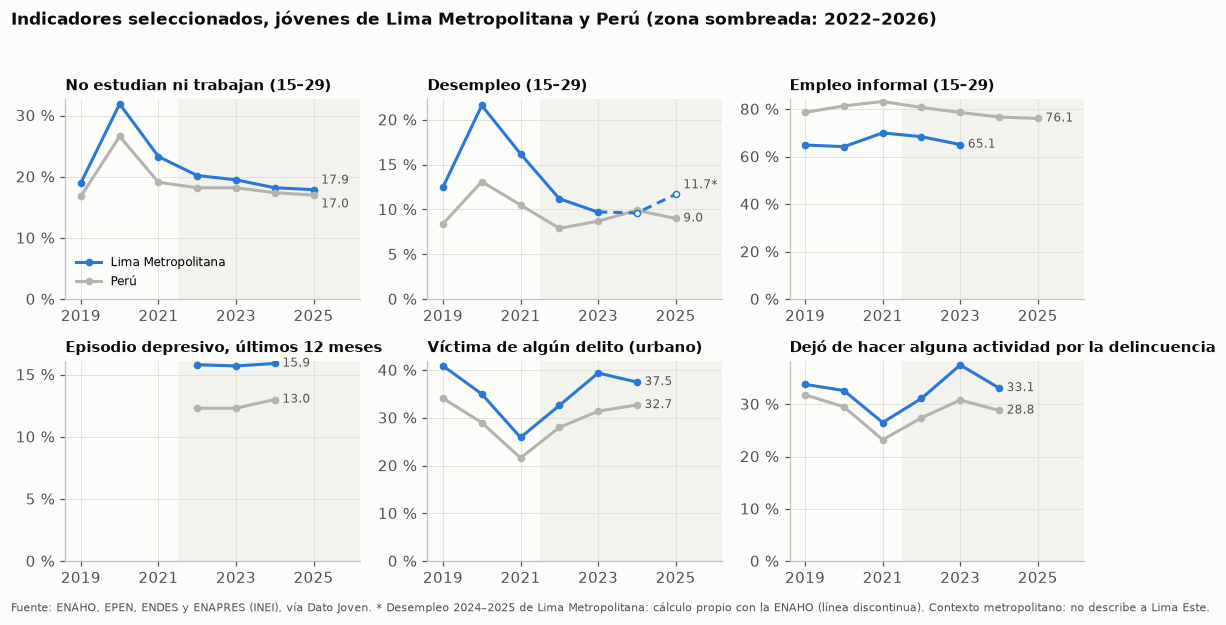

In [24]:
def serie(ax, tablero, indicador, titulo):
    finales = {}
    for nivel, color, etiqueta in [("lima_metropolitana", AZUL, "Lima Metropolitana"), ("nacional", GRIS_SERIE, "Perú")]:
        s = enc[(enc.nivel_geografico == nivel) & (enc.desagregacion == "total") & (enc.tablero == tablero) &
                (enc.indicador == indicador)].sort_values("anio")
        ax.plot(s.anio, s.valor, color=color, lw=2, marker="o", ms=4, label=etiqueta)
        if len(s):
            finales[nivel] = (s.anio.iloc[-1], s.valor.iloc[-1])
    # Si los dos valores finales están muy cerca, se separan las etiquetas verticalmente.
    cerca = (len(finales) == 2 and finales["lima_metropolitana"][0] == finales["nacional"][0]
             and abs(finales["lima_metropolitana"][1] - finales["nacional"][1]) < 2)
    for nivel, (x, v) in finales.items():
        dy = (6 if nivel == "lima_metropolitana" else -6) if cerca else 0
        ax.annotate(f"{v:.1f}", (x, v), xytext=(5, dy), textcoords="offset points", va="center",
                    fontsize=8, color=TINTA_2)
    ax.axvspan(2021.5, 2026.5, color=GRILLA, alpha=0.35, lw=0)
    ax.set_title(titulo, fontsize=10); ax.set_xlim(2018.6, 2026.2); ax.set_xticks(range(2019, 2027, 2))
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0f} %"); ax.set_ylim(bottom=0)

indicadores = [
    ("Jóvenes que no estudian ni trabajan (NINI)", "NINIS", "No estudian ni trabajan (15–29)"),
    ("Tasa de desempleo", "DESEMPLEO", "Desempleo (15–29)"),
    ("Empleo informal", "EMPLEO INFORMAL", "Empleo informal (15–29)"),
    ("Episodio depresivo", "EPISODIO DEPRESIVO", "Episodio depresivo, últimos 12 meses"),
    ("Jóvenes víctimas de algún hecho delictivo", "VÍCTIMA DE HECHO DELICTIVO", "Víctima de algún delito (urbano)"),
    ("factVictimizacionSeguridadCiudadana_ActividadQueDejóDeRealizar",
     "DEJÓ DE REALIZAR ALGUNA ACTIVIDAD PARA PROTEGERSE DE LA DELINCUENCIA EN LOS ÚLTIMOS 12 MESES",
     "Dejó de hacer alguna actividad por la delincuencia"),
]
fig, axes = plt.subplots(2, 3, figsize=(10, 5.6))
for ax, (t, i, titulo) in zip(axes.flat, indicadores):
    serie(ax, t, i, titulo)
# Desempleo de Lima Metropolitana 2024-2025: cálculo propio con la ENAHO (línea discontinua).
emp = pd.read_csv(P / "capa1_empleo_enaho.csv")
e = emp[(emp.nivel_geografico == "lima_metropolitana") & (emp.indicador == "DESEMPLEO") &
        (emp.desagregacion == "total") & (emp.anio >= 2023)].sort_values("anio")
ax = axes.flat[1]
for texto in list(ax.texts):  # la etiqueta de 2023 queda debajo de la extensión
    if texto.xy[0] == 2023:
        texto.remove()
ax.plot(e.anio, e.valor, color=AZUL, lw=2, ls=(0, (3, 2)), marker="o", ms=4, mfc=FONDO, markevery=[1, 2])
ax.annotate(f"{e.valor.iloc[-1]:.1f}*", (e.anio.iloc[-1], e.valor.iloc[-1]), xytext=(5, 6),
            textcoords="offset points", va="center", fontsize=8, color=TINTA_2)
axes.flat[0].legend(loc="lower left", fontsize=8)
fig.suptitle("Indicadores seleccionados, jóvenes de Lima Metropolitana y Perú (zona sombreada: 2022–2026)",
             x=0.01, ha="left", fontsize=11, fontweight="bold", color=TINTA)
fig.text(0.01, 0.005, "Fuente: ENAHO, EPEN, ENDES y ENAPRES (INEI), vía Dato Joven. * Desempleo 2024–2025 de Lima Metropolitana: cálculo propio con la ENAHO (línea discontinua). Contexto metropolitano: no describe a Lima Este.",
         fontsize=7.5, color=TINTA_2)
plt.tight_layout(rect=(0, 0.02, 1, 0.95)); plt.show()

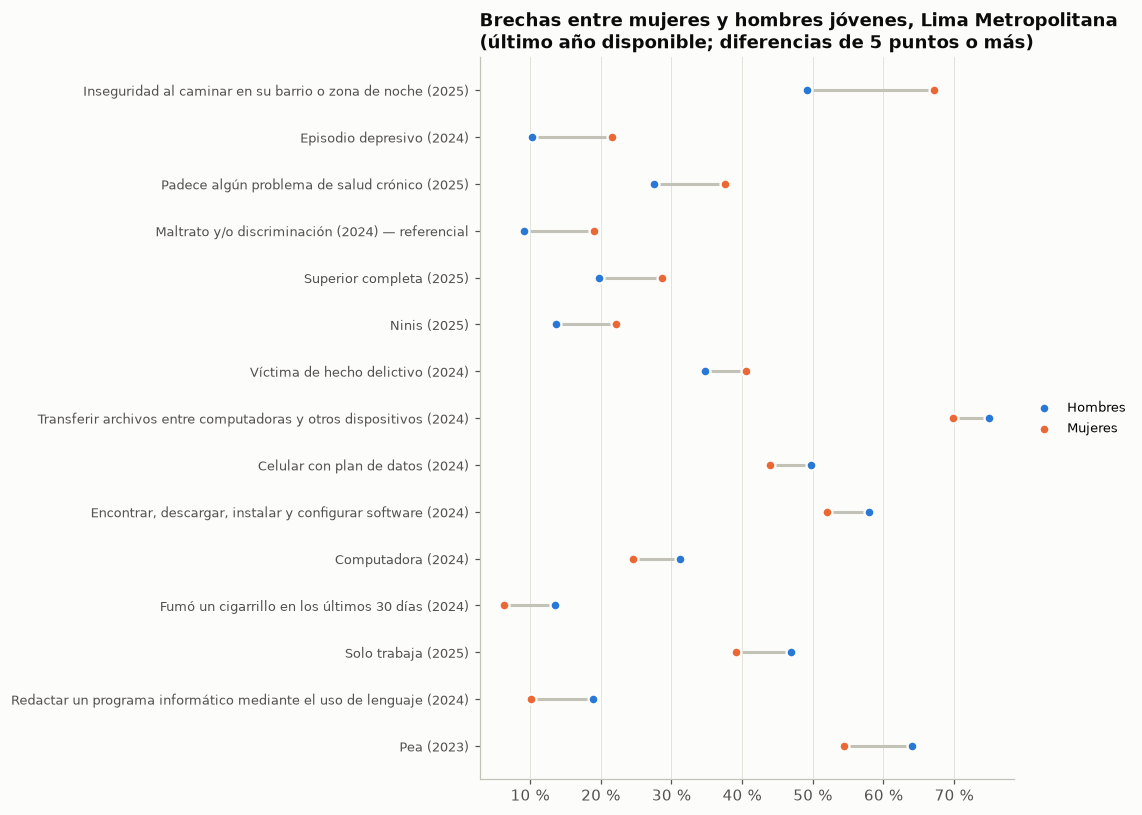

,indicador,años,mujeres,hombres,brecha (M−H),referencial
16,Pea,2022–2023,54.4,64.1,-9.7,
24,Redactar un programa informático mediante el uso de lenguaje,2022–2024,10.2,18.9,-8.7,
11,Solo trabaja,2022–2025,39.2,46.9,-7.7,
92,Fumó un cigarrillo en los últimos 30 días,2022–2024,6.3,13.5,-7.2,
29,Computadora,2022–2024,24.5,31.2,-6.7,
21,"Encontrar, descargar, instalar y configurar software",2022–2024,52.0,57.9,-5.9,
28,Celular con plan de datos,2022–2024,44.0,49.8,-5.8,
25,Transferir archivos entre computadoras y otros dispositivos,2022–2024,69.9,75.0,-5.1,
96,Víctima de hecho delictivo,2022–2024,40.6,34.8,5.8,
41,Ninis,2022–2025,22.1,13.7,8.4,


In [25]:
# Se excluye participación ciudadana (percepciones y confianza institucional) para centrar el gráfico en
# necesidades, y el NINI repetido en "Actividades que realizan los jóvenes".
brechas = resumen[resumen.mujeres.notna() & resumen.hombres.notna() & (resumen.unidad == "%")
                  & (resumen["dimensión"] != "Participación ciudadana") & (resumen.indicador != "Nini")].copy()
brechas["brecha (M−H)"] = brechas.mujeres - brechas.hombres
sel = brechas[brechas["brecha (M−H)"].abs() >= 5].sort_values("brecha (M−H)")
sel["etiqueta"] = [f"{i} ({a[-4:]}){' — referencial' if r == 'sí' else ''}"
                   for i, a, r in zip(sel.indicador, sel["años"], sel.referencial)]
fig, ax = plt.subplots(figsize=(10.5, 0.42 * len(sel) + 1.2))
y = np.arange(len(sel))
ax.hlines(y, sel.hombres, sel.mujeres, color=EJE, lw=2)
ax.scatter(sel.hombres, y, color=AZUL, s=42, zorder=3, label="Hombres", edgecolor=FONDO, linewidth=1.5)
ax.scatter(sel.mujeres, y, color=NARANJA, s=42, zorder=3, label="Mujeres", edgecolor=FONDO, linewidth=1.5)
ax.set_yticks(y, sel.etiqueta, fontsize=8.5)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0f} %")
ax.grid(axis="y", visible=False)
ax.set_title("Brechas entre mujeres y hombres jóvenes, Lima Metropolitana\n(último año disponible; diferencias de 5 puntos o más)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8.5)
plt.tight_layout(); plt.show()
sel[["indicador", "años", "mujeres", "hombres", "brecha (M−H)", "referencial"]]

### 5.1 Lectura (Lima Metropolitana; no atribuible a Lima Este)

**Educación.** En 2025, el 30,7 % de los jóvenes tiene educación universitaria como nivel alcanzado (25,6 % en 2022)
y la asistencia universitaria subió de 19,6 % a 25,6 %. Las mujeres superan a los hombres en educación
superior completa (28,7 % frente a 19,8 %). La secundaria completa a los 17–18 años bajó de 85,6 % a 82,6 %.

**Empleo.** La **informalidad** juvenil era de **65,1 %** en 2023 (último año disponible). Con la extensión
propia de la ENAHO, el **desempleo** fue de 9,6 % en 2024 y **11,7 % en 2025**. El aumento frente a 2023 (9,7 %)
no se distingue del error de muestreo. La participación laboral de las mujeres (53,8 % en 2025) sigue unos
nueve puntos por debajo de la de los hombres (62,9 %). En 2025, **17,9 % no estudia ni trabaja**: 22,1 % de las
mujeres y 13,7 % de los hombres.

**Salud.** La afiliación a algún seguro subió de 75 % a 88 % (2022–2025). El **episodio depresivo** afecta a
15,9 % de los jóvenes (2024), con una brecha marcada: **21,6 % de las mujeres y 10,3 % de los hombres**.

**Internet y competencias digitales.** El uso de internet es casi universal (96 %), pero sobre todo desde el
celular (92 %). Las habilidades más avanzadas son minoritarias: instalar o configurar software (55 %) y
programar (14,5 %). Usar fórmulas en hojas de cálculo subió de 68 % a 79 % (2022–2024).

**Seguridad.** En 2024, el **37,5 % fue víctima de algún delito** (32,6 % en 2022) y el **33 % dejó de hacer
alguna actividad para protegerse de la delincuencia**. El 58 % se siente inseguro al caminar de noche por su
barrio: 67 % de las mujeres y 49 % de los hombres. La "falta de seguridad ciudadana" como principal problema
del país pasó de 14,7 % a 28,0 % (2022–2024).

**Violencia y discriminación.** Entre las mujeres jóvenes con pareja, el 31,5 % sufrió violencia familiar
en el último año (2025). El 14,6 % declara haber sufrido maltrato o discriminación (valor referencial).

**Participación.** La participación en asociaciones u organizaciones es muy baja y poco precisa (0,7 %,
referencial). La confianza en la municipalidad distrital es de 24,5 % (2024).

Los cambios marcados como "no distinguibles" en las tablas pueden deberse al error de muestreo.

## 6. Síntesis de la Capa 1

| Dimensión | Evidencia distrital (Lima Este) | Contexto de Lima Metropolitana | Qué **no** se puede afirmar |
|---|---|---|---|
| Demografía | ~712 mil jóvenes en 2026; SJL y Ate concentran el 69 % | — | Tendencias de población joven 2022–2026 (series inestables) |
| Organización juvenil | Baja densidad de organizaciones en SJL, Ate, Lurigancho-Chosica y El Agustino; ninguna de deporte ni de ciudadanía | Participación en organizaciones muy baja (referencial) | Que haya poca organización real: el RENOJ solo capta organizaciones acreditadas |
| Voluntariado (señal) | Perfil: 85 % mujeres, 65 % estudiantes; experiencia en educación, ambiente y cultura | — | Intereses de la juventud en general; los intereses declarados no discriminan |
| Educación | — | Más acceso universitario; brecha a favor de las mujeres; menos secundaria completa a tiempo | Niveles educativos de Lima Este |
| Empleo / NINI | — | Informalidad del 65 % (2023); desempleo del 11,7 % (2025, cálculo propio); 1 de cada 5 mujeres no estudia ni trabaja | Situación laboral de Lima Este; informalidad después de 2023 |
| Maternidad adolescente | Tasas por encima de la mediana metropolitana en El Agustino, Santa Anita y Ate; nacimientos a la mitad desde 2019 | Embarazo adolescente (referencial) | Embarazos (solo se registran nacimientos) |
| Violencia | ~3 000 casos atendidos al año en los CEM; 94 % mujeres, 41 % de 15–19 años, 35 % violencia sexual | Violencia de pareja contra mujeres jóvenes: 31,5 % | Prevalencia de la violencia por distrito (los CEM registran atenciones) |
| Discapacidad | Certificación muy desigual entre distritos | — | Prevalencia (depende del acceso a los trámites) |
| Salud mental | — | Episodio depresivo 15,9 %; el doble en mujeres | Prevalencia en Lima Este |
| Competencias digitales | — | Acceso casi universal vía celular; brechas en habilidades avanzadas | Brechas digitales de Lima Este |
| Seguridad | — | Más de un tercio fue víctima; un tercio dejó de hacer actividades | Niveles de inseguridad en Lima Este |

Las decisiones metodológicas y los hallazgos de calidad de los datos están en `fuentes/metodologia_capa1.md`.